#### Import Libraries

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\My_Pc\AppData\Local\Temp\ipykernel_10812\1956827719.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="count", y="days", palette="viridis")


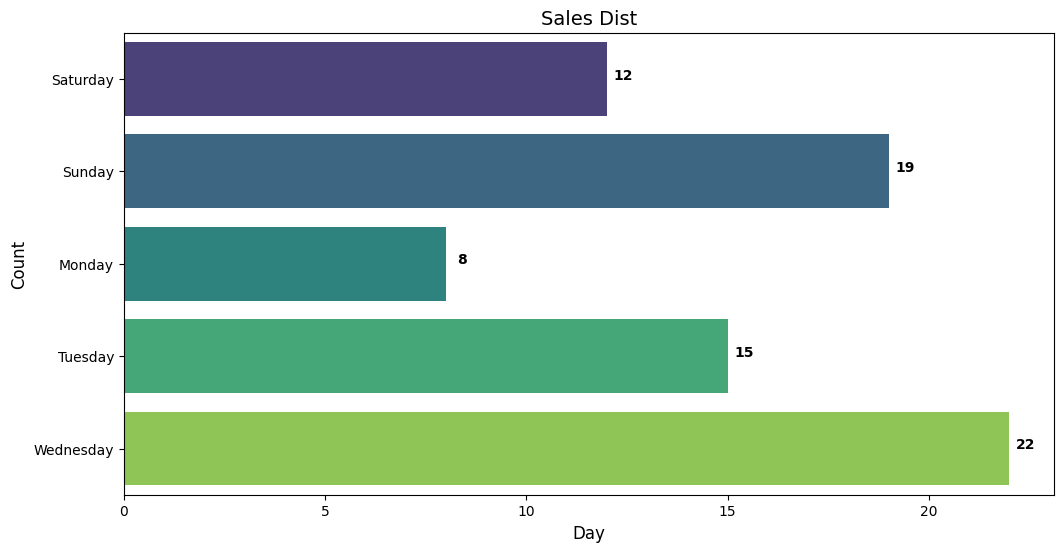

In [24]:
# داده‌های ساده: تعداد فروش در ۵ روز
days = ["Saturday", "Sunday", "Monday", "Tuesday", "Wednesday"]
sales_count = [12, 19, 8, 15, 22]
df = {"days":days,"count":sales_count}

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="count", y="days", palette="viridis")
plt.title("Sales Dist", fontsize=14)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Count", fontsize=12)

# اضافه کردن اعداد روی میله‌ها
for i, v in enumerate(df["count"]):
    plt.text(v+0.4, i, str(v), ha="center", fontweight="bold")

plt.show()

### Data Collection

In [ ]:
# connect to db
DB_PATH = "loan_manager_app/bank.db"
db_connection = sqlite3.connect(database=DB_PATH)

# get all data
query = """
SELECT 
    c.customer_id as customer_id,
    c.first_name,
    c.last_name,
    c.national_id,
    c.phone_number,
    c.age,
    c.marital_status,
    c.dependents,
    e.employment_type,
    e.employment_years,
    e.monthly_income,
    cp.credit_score,
    l.loan_amount,
    l.loan_term_months,
    l.loan_purpose,
    l.has_other_loans,
    l.late_payments_last_year,
    l.approved
FROM customers as c
JOIN employments as e ON c.customer_id = e.customer_id
JOIN credit_profiles as cp ON c.customer_id = cp.customer_id
JOIN loan_requests as l ON c.customer_id = l.customer_id

WHERE  l.approved IS NOT NULL
"""

df = pd.read_sql(sql=query,con = db_connection)
df.head()

,customer_id,first_name,last_name,national_id,phone_number,age,marital_status,dependents,employment_type,employment_years,monthly_income,credit_score,loan_amount,loan_term_months,loan_purpose,has_other_loans,late_payments_last_year,approved
0,1,نیایش,موحد,9697354961,09395310485,62,مجرد,0,بازنشسته,34.0,25945884,850.0,65425997,48,مسکن,0,0,1
1,2,آیدا,رفیعی,1939042955,09642621108,23,مجرد,0,فریلنس,0.0,22215582,643.0,100350425,48,تحصیل,1,0,0
2,3,حسين,علی شاهی,2193448329,09331191390,32,متأهل,3,بیکار,0.0,2921565,401.0,20699189,60,کسب_و_کار,0,0,0
3,4,ياسين,ولاشجردی,2625792787,09692749116,24,متأهل,1,کارمند,0.0,12246988,554.0,38623712,12,مسکن,0,1,0
4,5,ياسمين,قاضی,4721519026,09508157429,27,مجرد,0,کارمند,0.0,12260514,510.0,39933011,36,پزشکی,0,0,0


### Data Processing

#### Data Explroation (EDA)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              5000 non-null   int64  
 1   first_name               5000 non-null   str    
 2   last_name                5000 non-null   str    
 3   national_id              5000 non-null   str    
 4   phone_number             5000 non-null   str    
 5   age                      5000 non-null   int64  
 6   marital_status           5000 non-null   str    
 7   dependents               5000 non-null   int64  
 8   employment_type          5000 non-null   str    
 9   employment_years         5000 non-null   float64
 10  monthly_income           5000 non-null   int64  
 11  credit_score             4884 non-null   float64
 12  loan_amount              5000 non-null   int64  
 13  loan_term_months         5000 non-null   int64  
 14  loan_purpose             5000 non-n

In [8]:
df.describe()

,customer_id,age,dependents,employment_years,monthly_income,credit_score,loan_amount,loan_term_months,has_other_loans,late_payments_last_year,approved
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,4884.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000
mean,2500.500000,43.559600,1.259000,14.151800,2.267798e+07,707.760647,1.130676e+08,42.15120,0.069200,0.436200,0.604600
std,1443.520003,12.809077,1.479174,12.611779,8.004864e+06,132.604369,5.792094e+07,20.40995,0.253819,0.791236,0.488985
min,1.000000,22.000000,0.000000,0.000000,2.761542e+06,393.000000,5.636924e+06,12.00000,0.000000,0.000000,0.000000
25%,1250.750000,32.000000,0.000000,1.000000,1.817642e+07,600.000000,6.973720e+07,24.00000,0.000000,0.000000,0.000000
50%,2500.500000,43.000000,1.000000,12.000000,2.287948e+07,723.000000,1.044943e+08,48.00000,0.000000,0.000000,1.000000
75%,3750.250000,55.000000,2.000000,25.000000,2.772177e+07,850.000000,1.513316e+08,60.00000,0.000000,1.000000,1.000000
max,5000.000000,65.000000,4.000000,45.000000,4.553975e+07,850.000000,3.501925e+08,72.00000,1.000000,4.000000,1.000000


In [9]:

distinct_count = df.nunique()

In [10]:
distinct_count

customer_id                5000
first_name                  157
last_name                   101
national_id                5000
phone_number               5000
age                          44
marital_status                2
dependents                    5
employment_type               6
employment_years             46
monthly_income             4998
credit_score                449
loan_amount                5000
loan_term_months              6
loan_purpose                  6
has_other_loans               2
late_payments_last_year       5
approved                      2
dtype: int64

In [11]:
df.isnull().sum()

customer_id                  0
first_name                   0
last_name                    0
national_id                  0
phone_number                 0
age                          0
marital_status               0
dependents                   0
employment_type              0
employment_years             0
monthly_income               0
credit_score               116
loan_amount                  0
loan_term_months             0
loan_purpose                 0
has_other_loans              0
late_payments_last_year      0
approved                     0
dtype: int64